In [1]:
import pandas as pd
import numpy as np
import sqlalchemy as sa
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score


# histogramy

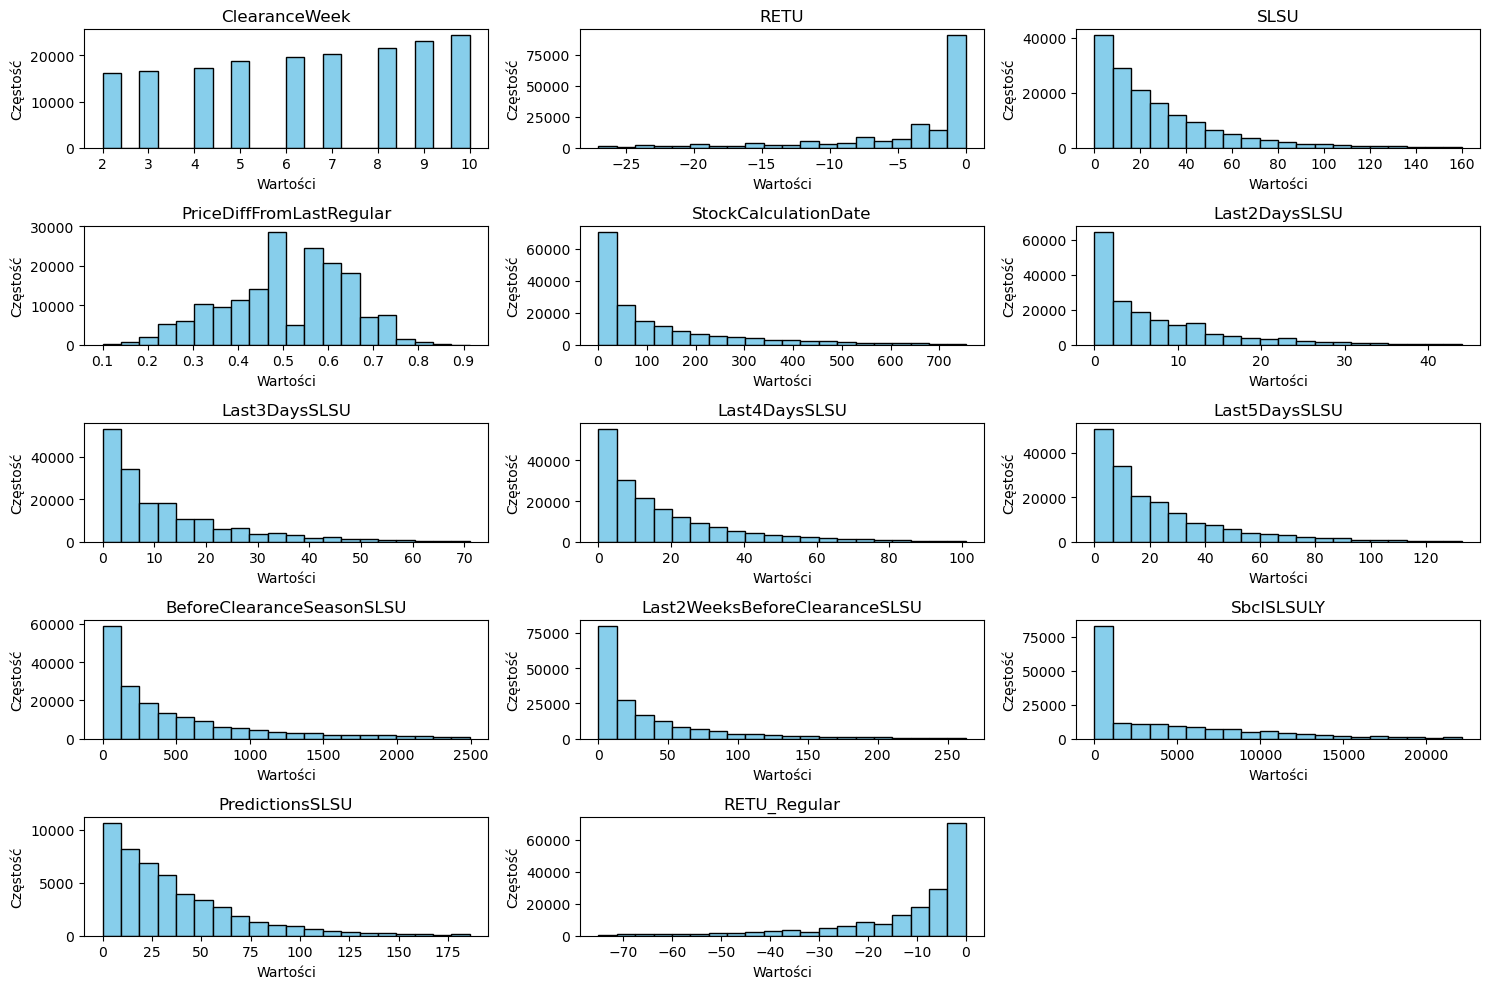

In [62]:
num_cols = df_cleaned.select_dtypes(include=['number']).columns


plt.figure(figsize=(15, 10))  
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols) // 3 + 1, 3, i)
    plt.hist(df_cleaned[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(col)
    plt.xlabel('Wartości')
    plt.ylabel('Częstość')

plt.tight_layout()
plt.show()


(-30.0, 0.0)

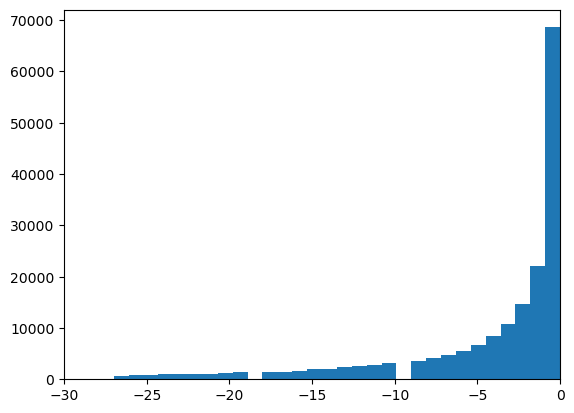

In [24]:
plt.hist(df_cleaned['RETU'], bins=30)
plt.xlim(-30, 0)

In [64]:
df_cleaned["RETU"].nsmallest(5)

1243   -27.0
4546   -27.0
6031   -27.0
8181   -27.0
9423   -27.0
Name: RETU, dtype: float64

# korelacje - heatmap

In [63]:
df_cleaned.corr(numeric_only=True)

,ClearanceWeek,RETU,SLSU,PriceDiffFromLastRegular,StockCalculationDate,Last2DaysSLSU,Last3DaysSLSU,Last4DaysSLSU,Last5DaysSLSU,BeforeClearanceSeasonSLSU,Last2WeeksBeforeClearanceSLSU,SbclSLSULY,PredictionsSLSU,RETU_Regular
ClearanceWeek,1.000000,0.259540,-0.134681,0.381686,-0.311823,-0.050003,-0.049471,-0.045860,-0.034251,0.006482,0.099116,-0.160894,-0.193430,-0.089185
RETU,0.259540,1.000000,-0.468828,0.221664,-0.250377,-0.370408,-0.339223,-0.332164,-0.326510,0.045208,-0.093397,-0.001443,-0.332641,0.360100
SLSU,-0.134681,-0.468828,1.000000,-0.011241,0.579575,0.694607,0.737383,0.751620,0.746314,0.043492,0.270769,0.122371,0.697860,-0.220723
PriceDiffFromLastRegular,0.381686,0.221664,-0.011241,1.000000,-0.088778,-0.037347,-0.013326,-0.010185,-0.005492,-0.043757,-0.142500,-0.044792,-0.016390,0.218826
StockCalculationDate,-0.311823,-0.250377,0.579575,-0.088778,1.000000,0.385136,0.416881,0.421469,0.410461,-0.044241,0.098238,0.149615,0.638372,-0.036549
Last2DaysSLSU,-0.050003,-0.370408,0.694607,-0.037347,0.385136,1.000000,0.950076,0.915898,0.880726,0.058342,0.290358,0.087496,0.596709,-0.292189
Last3DaysSLSU,-0.049471,-0.339223,0.737383,-0.013326,0.416881,0.950076,1.000000,0.977579,0.951403,0.075613,0.323887,0.104238,0.641648,-0.279170
Last4DaysSLSU,-0.045860,-0.332164,0.751620,-0.010185,0.421469,0.915898,0.977579,1.000000,0.984927,0.081362,0.338294,0.104861,0.650962,-0.283790
Last5DaysSLSU,-0.034251,-0.326510,0.746314,-0.005492,0.410461,0.880726,0.951403,0.984927,1.000000,0.085722,0.344997,0.098962,0.655386,-0.289998
BeforeClearanceSeasonSLSU,0.006482,0.045208,0.043492,-0.043757,-0.044241,0.058342,0.075613,0.081362,0.085722,1.000000,0.338939,0.091316,0.022518,-0.191226


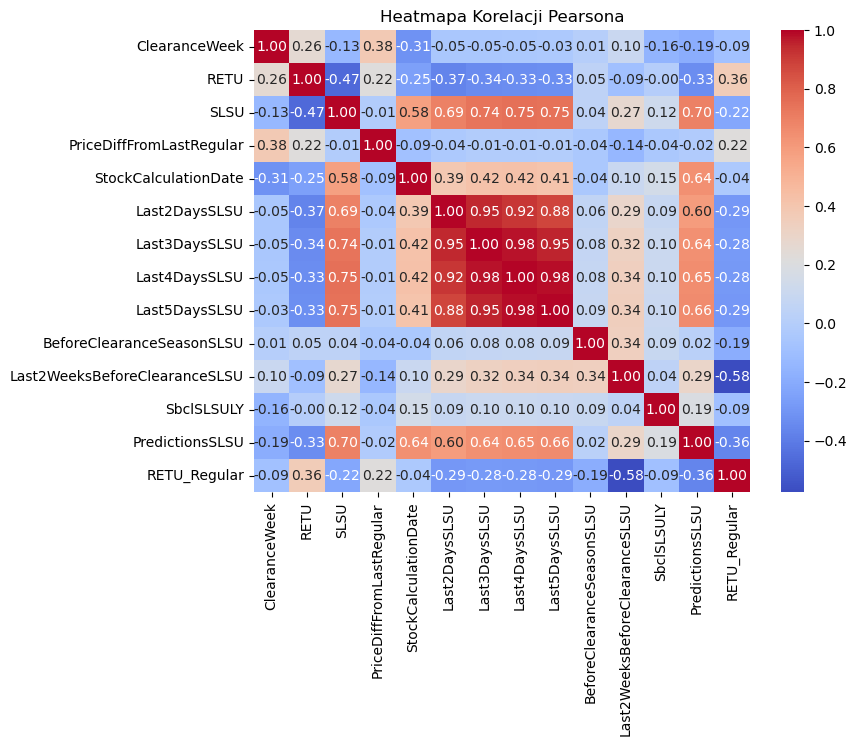

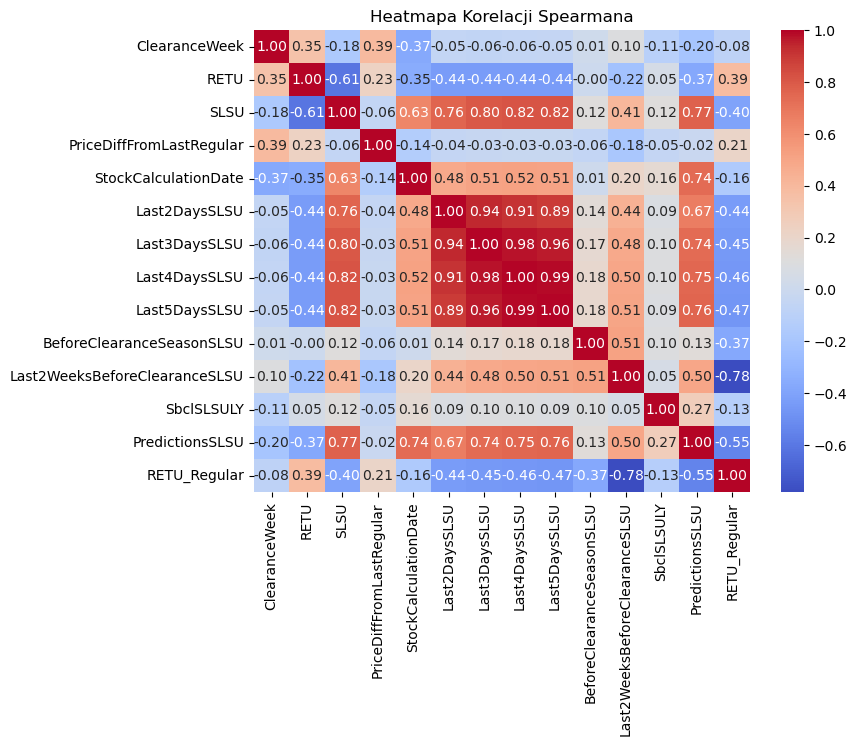

In [19]:
df_cleaned.corr(numeric_only=True)

pearson_corr = df_cleaned.corr(method='pearson', numeric_only=True)

spearman_corr = df_cleaned.corr(method='spearman', numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    pearson_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    cbar=True
)
plt.title("Heatmapa Korelacji Pearsona")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    cbar=True
)
plt.title("Heatmapa Korelacji Spearmana")
plt.show()



# wykresy RETU z innymi zmiennymi

Text(0.5, 1.0, 'Wykres punktowy')

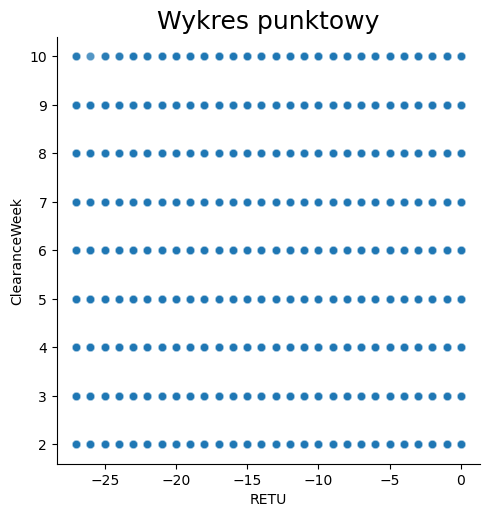

In [27]:
sns.relplot(x="RETU", y="ClearanceWeek", data=df_cleaned, alpha=0.3)
plt.title('Wykres punktowy', fontsize=18)

Text(0.5, 1.0, 'Wykres punktowy')

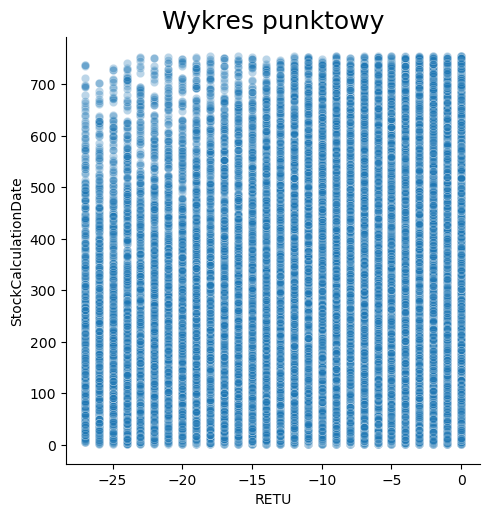

In [29]:
sns.relplot(x="RETU", y="StockCalculationDate", data=df_cleaned, alpha=0.3)
plt.title('Wykres punktowy', fontsize=18)

Text(0.5, 1.0, 'Wykres punktowy')

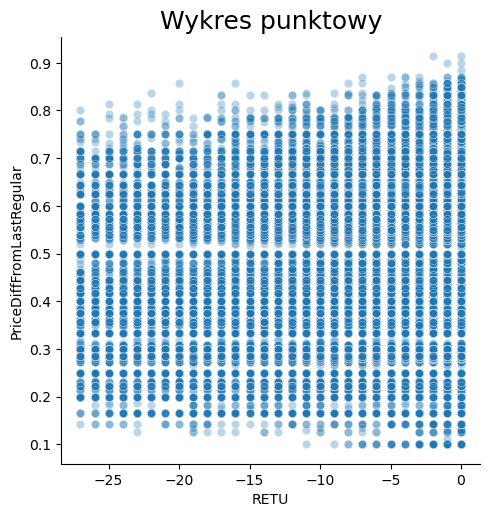

In [30]:
sns.relplot(x="RETU", y="PriceDiffFromLastRegular", data=df_cleaned, alpha=0.3)
plt.title('Wykres punktowy', fontsize=18)

Text(0.5, 1.0, 'Wykres punktowy')

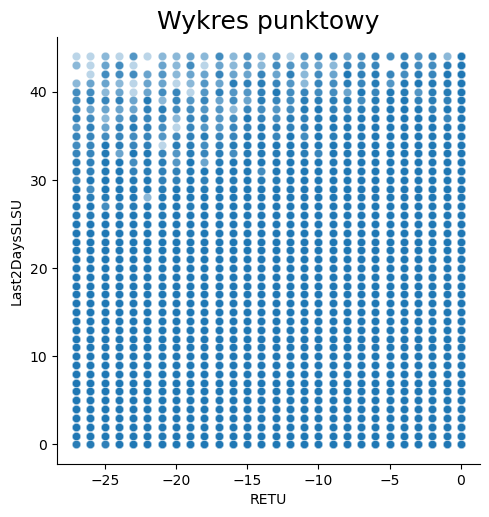

In [31]:
sns.relplot(x="RETU", y="Last2DaysSLSU", data=df_cleaned, alpha=0.3)
plt.title('Wykres punktowy', fontsize=18)

Text(0.5, 1.0, 'Wykres punktowy')

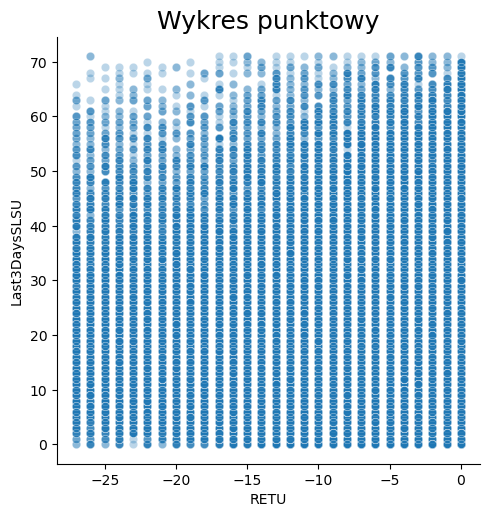

In [32]:
sns.relplot(x="RETU", y="Last3DaysSLSU", data=df_cleaned, alpha=0.3)
plt.title('Wykres punktowy', fontsize=18)

Text(0.5, 1.0, 'Wykres punktowy')

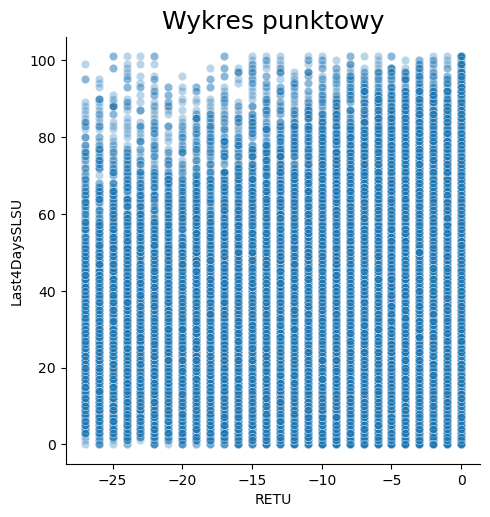

In [33]:
sns.relplot(x="RETU", y="Last4DaysSLSU", data=df_cleaned, alpha=0.3)
plt.title('Wykres punktowy', fontsize=18)

Text(0.5, 1.0, 'Wykres punktowy')

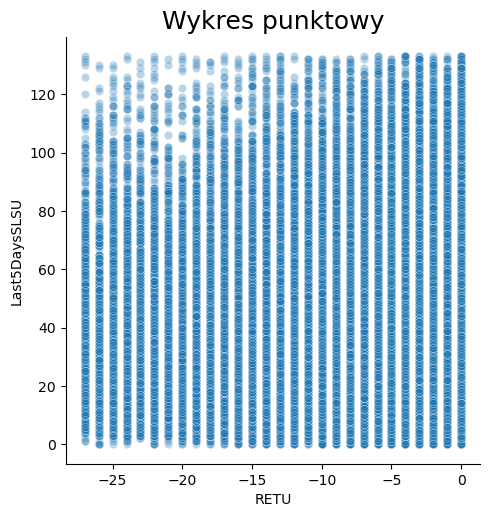

In [34]:
sns.relplot(x="RETU", y="Last5DaysSLSU", data=df_cleaned, alpha=0.3)
plt.title('Wykres punktowy', fontsize=18)

Text(0.5, 1.0, 'Wykres punktowy')

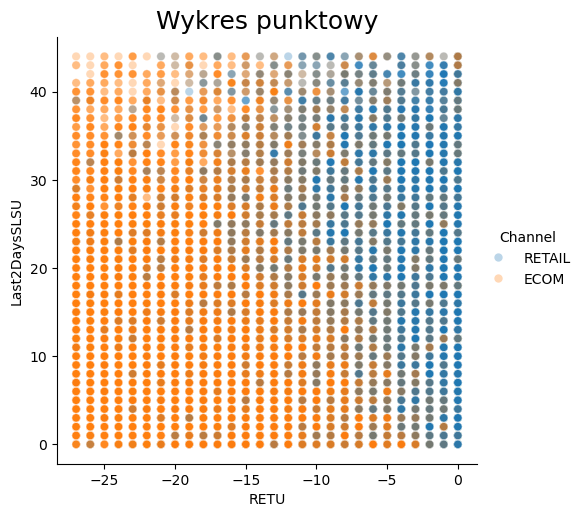

In [35]:
sns.relplot(x="RETU", y="Last2DaysSLSU", hue="Channel", data=df_cleaned, alpha=0.3)
plt.title('Wykres punktowy', fontsize=18)

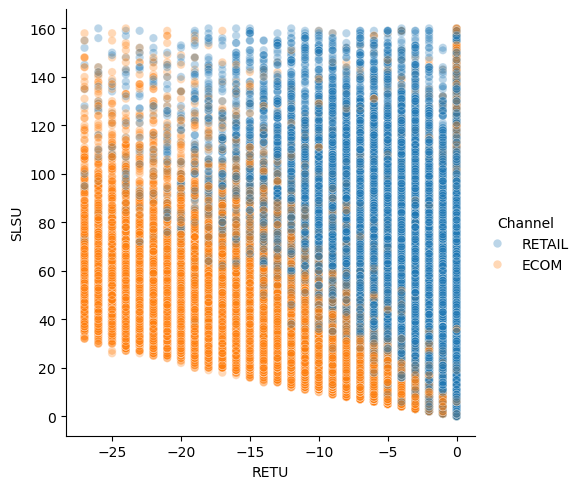

In [36]:
sns.relplot(x="RETU", y="SLSU", hue="Channel", data=df_cleaned, alpha=0.3)


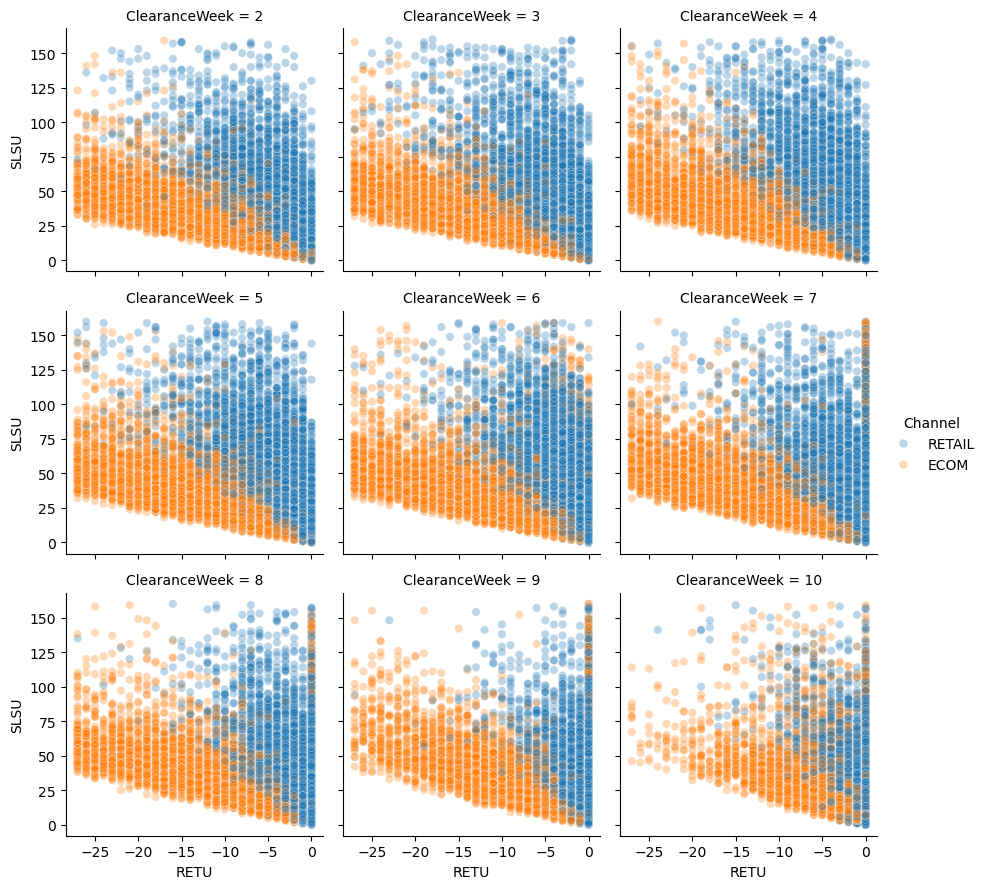

In [37]:
sns.relplot(x="RETU", y="SLSU", hue="Channel", col="ClearanceWeek", col_wrap=3, data=df_cleaned, height=3, alpha=0.3)